In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end

  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using StaticArrays
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

In [3]:
Threads.nthreads()

4

In [4]:
include("../scripts/TesselationCore.jl")
import .TesselationCore

BVH = TesselationCore.BVH
point3 = TesselationCore.point3

SVector{3, Float64} (alias for SArray{Tuple{3}, Float64, 1, 3})

In [5]:
import illustris_julia as il


basePath = "../../DTFE/Illustris3/output";

fields = ["SubhaloMass","SubhaloCM"];
subhalos = il.groupcat.loadSubhalos(basePath,135,fields)

positions = subhalos["SubhaloCM"]
print("done") #otherwise floods GitHub with output 

done

In [16]:
gap = 1
points = positions[:,1:gap:end]
ps = [point3(points[1,i], points[2,i], points[3,i]) for i in 1:size(points,2)]

bvh,tes,tets = TesselationCore.standardEstimator(ps,10)
print("done")

done

In [17]:
println(size(ps))
print(size(ps,1)^(1/3))


(121209,)
49.489335525239746

In [18]:
N = 32

width = 75000

step = width/N


xs = bvh.bbox[1,1]:step:bvh.bbox[1,2]
ys = bvh.bbox[2,1]:step:bvh.bbox[2,2]

z = (bvh.bbox[3,2] + bvh.bbox[3,1])/2

dens = zeros(N,N)
print("Done")

Done

In [19]:
@btime TesselationCore.DTFE([z,z,z],bvh,tets,tes)

  5.693 ms (34 allocations: 531.81 KiB)


1.3945484293282983e-12

In [ ]:
@btime for (i,x) in pairs(xs)
    for (j,y) in pairs(ys)
        dens[i,j] = TesselationCore.DTFE([x,y,z],bvh,tets,tes)
    end
end
med = median(dens) # Fixed allocations! Lovely!

  6.567 s (42982 allocations: 533.05 MiB)


1.6595500547063428e-12

In [21]:
.005693 * N*N # Still not as efficent, but we are cooking

5.829632

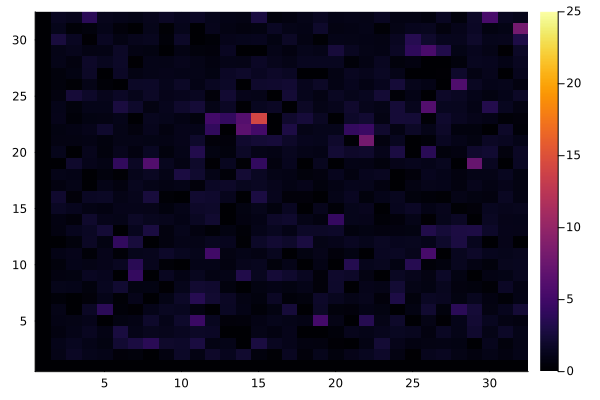

In [22]:
Plots.heatmap(dens ./med,clim=(0,25))

In [ ]:
@btime for (i,x) in pairs(xs)
    for (j,y) in pairs(ys)
        @inbounds dens[i,j] = TesselationCore.DTFE([x,y,z],bvh,tets,tes)
    end
end #tad slower

  6.927 s (42982 allocations: 533.05 MiB)


In [ ]:
@btime @inbounds for (i,x) in pairs(xs)
    @inbounds for (j,y) in pairs(ys)
        dens[i,j] = TesselationCore.DTFE([x,y,z],bvh,tets,tes)
    end
end #even slightlier slower

  6.667 s (42982 allocations: 533.05 MiB)


In [ ]:
@btime Threads.@threads for i in 1:size(xs,1)
    x = xs[i]
    for (j,y) in pairs(ys)
        dens[i,j] = TesselationCore.DTFE([x,y,z],bvh,tets,tes)
    end # Better than 2 times!
end #TODO run on virgo on Monday and see how much performance we can squeeze

  2.489 s (42784 allocations: 533.05 MiB)


In [26]:
@btime dens = [TesselationCore.DTFE([x, y, z], bvh, tets, tes) for x in xs, y in ys] # faster and fewer allocs than fors. A bit embarassing considering PSDTFE already shows this
print("done")

  6.586 s (34516 allocations: 532.84 MiB)
done

In [27]:
@btime dens = TesselationCore.DTFE.([ [x,y,z] for x in xs, y in ys ], Ref(bvh), Ref(tets), Ref(tes)) # equivalent to inbounds, but good
print("done")


  6.535 s (34520 allocations: 532.85 MiB)
done

In [ ]:
@btime Threads.@threads for i in eachindex(xs)
    x = xs[i]
    for j in eachindex(ys)
        y = ys[j]
        dens[i,j] = TesselationCore.DTFE([x,y,z], bvh, tets, tes) # tad faster than multithread
    end
end

  2.133 s (36608 allocations: 532.87 MiB)


In [ ]:
@btime Threads.@threads for i in eachindex(xs)
    x = xs[i]
    @inbounds for (j,y) in pairs(ys) # pairs is fine it seems when I am not allocating 90 gigs, lol.
        dens[i,j] = TesselationCore.DTFE([x,y,z], bvh, tets, tes) 
    end
end

  1.724 s (42784 allocations: 533.05 MiB)
